In [2]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

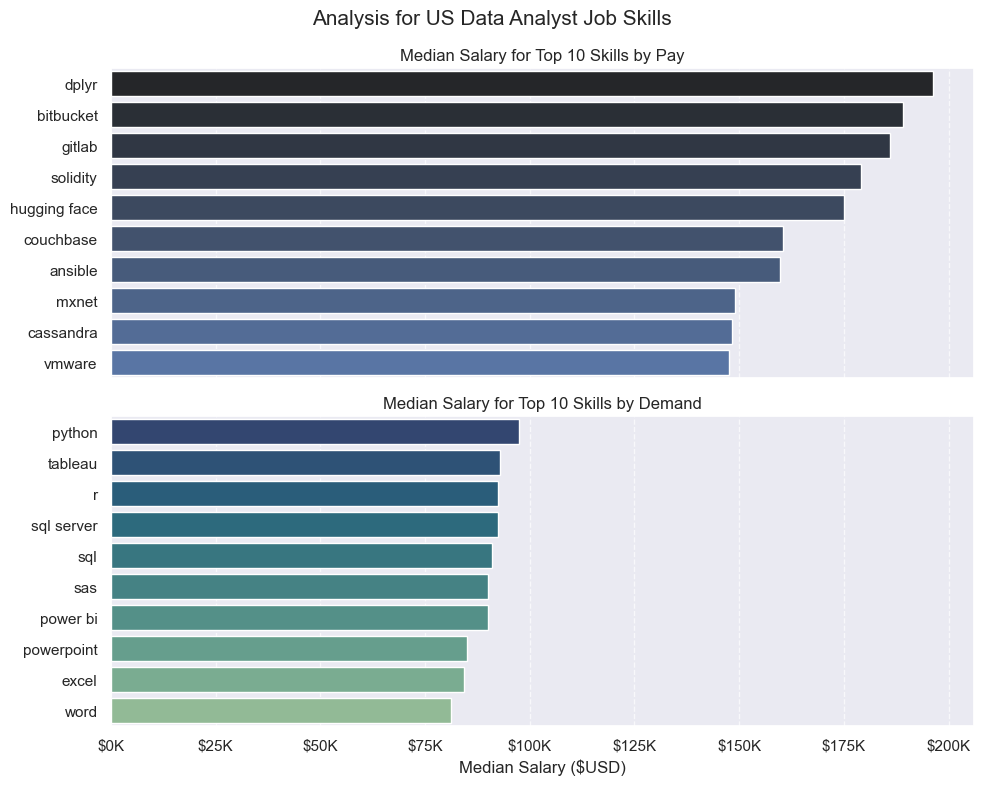

In [ ]:
# --- DATA PREPARATION ---

# Filter for Data Analyst roles in the US and create a deep copy to avoid SettingWithCopyWarning
df_DA_ind = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

# Expand the list of skills into individual rows so each skill can be analyzed separately
df_DA_ind = df_DA_ind.explode('job_skills')

# Remove rows where salary data is missing to ensure the median calculation is accurate
df_DA_ind = df_DA_ind.dropna(subset=['salary_year_avg'])

# Group by skill and calculate the median salary and the count (size) of postings for each
df_DA_ind = df_DA_ind.groupby('job_skills')['salary_year_avg'].agg(['median', 'size'])

# --- SORTING FOR VISUALIZATION ---

# Get the 10 most frequent skills, then sort them by salary so the bar chart flows logically
skills_demand = df_DA_ind.sort_values(by='size', ascending=False).head(10).sort_values(by='median', ascending=False)

# Get the top 10 highest-paying skills regardless of demand
skills_pay = df_DA_ind.sort_values(by='median', ascending=False).head(10)

# --- PLOTTING ---

# Create a figure with two stacked subplots sharing the same X-axis scale for direct comparison
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
sns.set_theme() ## default theme

# Plot Demand chart: Horizontal bars, median salary on X-axis, remove legend for clarity
# skills_demand.plot(kind='barh', y='median', ax=ax[0], legend=False).invert_yaxis() --- before seaborn
sns.barplot(data=skills_demand, x='median', y=skills_demand.index, hue=skills_demand.index , palette='crest_r', ax=ax[1], legend=False)
ax[1].set_ylabel('')
ax[1].set_title('Median Salary for Top 10 Skills by Demand')
ax[1].grid(True, axis='x', linestyle='--', alpha=0.7) # Add vertical grid lines
ax[1].set_axisbelow(True) # Ensure grid lines are behind the bars

# Formatting the X-axis: Convert raw numbers to $K format (e.g., 100000 -> $100K)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}K'))
ax[1].set_xlabel('Median Salary ($USD)')

# Plot Pay chart: Horizontal bars, median salary on X-axis
# skills_pay.plot(kind='barh', y='median', ax=ax[1], legend=False).invert_yaxis() -- before seaborn
sns.barplot(data=skills_pay, x='median', y=skills_pay.index, hue=skills_pay.index , palette='dark:b', ax=ax[0], legend=False)
ax[0].set_ylabel('')
ax[0].set_title('Median Salary for Top 10 Skills by Pay')
ax[0].grid(True, axis='x', linestyle='--', alpha=0.7)
ax[0].set_axisbelow(True)

# Set an overall title for the entire dashboard
fig.suptitle('Analysis for US Data Analyst Job Skills', fontsize=15)
plt.tight_layout() # Adjust layout to prevent label clipping
plt.show()